# HDB Resale Price Regression — Notebook 14: Revised Final Model

Notebooks 12–13 stress-tested Model 10 with five diagnostics and three robustness checks. Two variables did not survive:

- **`price_has_168`** — the "一路发 prosperity all the way" premium (+$32,795 in OLS) collapsed to $17,233 under median regression and lost significance (p = 0.198). The OLS estimate was inflated by a handful of expensive transactions.
- **`cny_month`** — the $59,310 "Chinese New Year month" effect was an aliasing artifact. March 2026 was the only month in the dataset where every transaction fell in a CNY month, making `cny_month` perfectly collinear with the March 2026 month dummy. Once resolved, the true effect is ~$880 and not significant.

This notebook builds **Model 11**: Model 10 minus these two variables. Everything that survived — the lucky-8 premium, the block-4 discount, all distance and structural variables — stays in.

**What survived robustness checks:**
| Variable | OLS | LAD | Cook's D removal | Verdict |
|---|---|---|---|---|
| num_eights_tail | +$1,070 | +$1,371 | +$1,354 | Robust — strengthens |
| block_has_4 | -$10,160 | -$8,721 | -$8,557 | Robust |
| All distance vars | Stable | Stable | Stable | Robust |
| All structural vars | Stable | Stable | Stable | Robust |

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)
library(car)

df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))
df$ln_price <- log(df$resale_price)

# Model 11: Model 10 minus price_has_168 and cny_month
model11 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              block_has_4 +
              month_factor,
            data = df)

# Model 10 for comparison
model10 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df)

cat(sprintf('Model 10 (original):  R\u00b2 = %.4f, Adj R\u00b2 = %.4f, %d parameters\n',
    summary(model10)$r.squared, summary(model10)$adj.r.squared, length(coef(model10))))
cat(sprintf('Model 11 (revised):   R\u00b2 = %.4f, Adj R\u00b2 = %.4f, %d parameters\n',
    summary(model11)$r.squared, summary(model11)$adj.r.squared, length(coef(model11))))
cat(sprintf('R\u00b2 change:            %+.4f\n',
    summary(model11)$r.squared - summary(model10)$r.squared))
cat(sprintf('Observations:         %s\n', format(nrow(df), big.mark = ',')))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Model 10 (original):  R² = 0.9023, Adj R² = 0.9021, 87 parameters


Model 11 (revised):   R² = 0.9023, Adj R² = 0.9021, 85 parameters


R² change:            -0.0001


Observations:         51,740


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode

The following object is masked from ‘package:purrr’:

    some



## Model 11: full coefficient table

All coefficients with HC1 robust standard errors. Town dummies, flat model dummies, and month fixed effects listed separately.

In [3]:
%%R
robust11 <- coeftest(model11, vcov = vcovHC(model11, type = 'HC1'))

# Key variables (non-dummy)
key_vars <- c('(Intercept)', 'floor_area_sqm', 'storey_mid',
              'remaining_lease_years', 'remaining_lease_sq',
              'dist_cbd_km', 'mrt_dist_m', 'hawker_dist_m',
              'popular_school_dist_m',
              'park_dist_m', 'hospital_dist_m',
              'columbarium_dist_m', 'temple_dist_m',
              'coast_dist_m',
              'num_eights_tail',
              'block_has_4')

cat(sprintf('%-30s %12s %10s %8s\n', 'Variable', 'Coefficient', 'Robust SE', 'p-value'))
cat(paste(rep('=', 63), collapse = ''), '\n')

for (v in key_vars) {
    if (v %in% rownames(robust11)) {
        coef_val <- robust11[v, 'Estimate']
        se <- robust11[v, 'Std. Error']
        p <- robust11[v, 'Pr(>|t|)']
        sig <- ifelse(p < 0.001, '***', ifelse(p < 0.01, '**', ifelse(p < 0.05, '*', '')))
        cat(sprintf('%-30s $%+10.0f %10.0f %7.4f %s\n', v, coef_val, se, p, sig))
    }
}

# Flat type dummies
cat(sprintf('\n--- Flat type (ref: 1 ROOM) ---\n'))
ft_rows <- grep('^flat_type', rownames(robust11))
for (i in ft_rows) {
    v <- rownames(robust11)[i]
    label <- gsub('flat_type', '', v)
    coef_val <- robust11[v, 'Estimate']
    p <- robust11[v, 'Pr(>|t|)']
    sig <- ifelse(p < 0.001, '***', ifelse(p < 0.01, '**', ifelse(p < 0.05, '*', '')))
    cat(sprintf('  %-28s $%+10.0f %7.4f %s\n', label, coef_val, p, sig))
}

# Flat model dummies
cat(sprintf('\n--- Flat model (ref: 2-room) ---\n'))
fm_rows <- grep('^flat_model_grouped', rownames(robust11))
for (i in fm_rows) {
    v <- rownames(robust11)[i]
    label <- gsub('flat_model_grouped', '', v)
    coef_val <- robust11[v, 'Estimate']
    p <- robust11[v, 'Pr(>|t|)']
    sig <- ifelse(p < 0.001, '***', ifelse(p < 0.01, '**', ifelse(p < 0.05, '*', '')))
    cat(sprintf('  %-28s $%+10.0f %7.4f %s\n', label, coef_val, p, sig))
}

# Town dummies
cat(sprintf('\n--- Town (ref: ANG MO KIO) ---\n'))
town_rows <- grep('^town', rownames(robust11))
for (i in town_rows) {
    v <- rownames(robust11)[i]
    label <- gsub('town', '', v)
    coef_val <- robust11[v, 'Estimate']
    p <- robust11[v, 'Pr(>|t|)']
    sig <- ifelse(p < 0.001, '***', ifelse(p < 0.01, '**', ifelse(p < 0.05, '*', '')))
    cat(sprintf('  %-28s $%+10.0f %7.4f %s\n', label, coef_val, p, sig))
}

cat(sprintf('\n+ %d month fixed effects (omitted)\n',
    length(grep('month_factor', rownames(robust11)))))

# F-statistic
s <- summary(model11)
cat(sprintf('\nF-statistic: %.1f on %d and %d DF, p-value: %s\n',
    s$fstatistic[1], s$fstatistic[2], s$fstatistic[3],
    format.pval(pf(s$fstatistic[1], s$fstatistic[2], s$fstatistic[3], lower.tail=FALSE))))

Variable                        Coefficient  Robust SE  p-value


(Intercept)                    $   -242141      17203  0.0000 ***


floor_area_sqm                 $     +5422        160  0.0000 ***


storey_mid                     $     +5454         69  0.0000 ***


remaining_lease_years          $    +11387        363  0.0000 ***


...

  TOA PAYOH                    $     -6605  0.0692 


  WOODLANDS                    $    -86114  0.0000 ***


  YISHUN                       $    -15176  0.0006 ***



+ 23 month fixed effects (omitted)



F-statistic: 5676.6 on 84 and 51655 DF, p-value: < 2.22e-16


## Log model equivalent

Same Model 11 variables with ln(resale_price) as the dependent variable, plus the floor_area × Terrace interaction from Notebook 11.

In [4]:
%%R
df$is_terrace <- ifelse(df$flat_model_grouped == 'Terrace', 1, 0)

model11_log <- lm(ln_price ~ town + flat_type + floor_area_sqm * is_terrace + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              block_has_4 +
              month_factor,
            data = df)

cat(sprintf('Model 11 (raw):   R\u00b2 = %.4f\n', summary(model11)$r.squared))
cat(sprintf('Model 11 (log):   R\u00b2 = %.4f\n', summary(model11_log)$r.squared))

# Compare predictions on dollar scale
df$pred_raw <- predict(model11, df)
df$pred_log <- exp(predict(model11_log, df))

cat(sprintf('\nPrediction comparison (dollar scale):\n'))
cat(sprintf('  %-25s %12s %12s\n', '', 'Raw model', 'Log model'))
cat(paste(rep('-', 50), collapse = ''), '\n')
cat(sprintf('  %-25s $%10s $%10s\n', 'Mean absolute error',
    format(round(mean(abs(df$resale_price - df$pred_raw))), big.mark = ','),
    format(round(mean(abs(df$resale_price - df$pred_log))), big.mark = ',')))
cat(sprintf('  %-25s $%10s $%10s\n', 'Median absolute error',
    format(round(median(abs(df$resale_price - df$pred_raw))), big.mark = ','),
    format(round(median(abs(df$resale_price - df$pred_log))), big.mark = ',')))
cat(sprintf('  %-25s %12d %12d\n', 'Negative predictions',
    sum(df$pred_raw < 0), sum(df$pred_log < 0)))

# Key coefficients comparison
cat('\nKey coefficients (log model, approximate % interpretation):\n')
robust_log <- coeftest(model11_log, vcov = vcovHC(model11_log, type = 'HC1'))
log_vars <- c('floor_area_sqm', 'storey_mid', 'remaining_lease_years',
              'dist_cbd_km', 'mrt_dist_m', 'columbarium_dist_m', 'temple_dist_m',
              'num_eights_tail', 'block_has_4')

cat(sprintf('%-25s %12s %12s\n', 'Variable', 'Raw ($)', 'Log (%)'))
cat(paste(rep('-', 50), collapse = ''), '\n')
for (v in log_vars) {
    if (v %in% rownames(robust11) & v %in% rownames(robust_log)) {
        c_raw <- robust11[v, 'Estimate']
        c_log <- robust_log[v, 'Estimate'] * 100
        cat(sprintf('%-25s $%+10.0f %+10.3f%%\n', v, c_raw, c_log))
    }
}

Model 11 (raw):   R² = 0.9023


Model 11 (log):   R² = 0.9379



Prediction comparison (dollar scale):


                               Raw model    Log model


--------------------------------------------------

...

mrt_dist_m                $       -80     -0.012%


columbarium_dist_m        $        +8     +0.001%


temple_dist_m             $       -25     -0.003%


num_eights_tail           $     +1161     +0.244%


block_has_4               $    -10037     -1.340%


## Lucky-8 premium by price level

The lucky-8 premium is not constant — it reverses for the cheapest flats and grows with price. Price quartiles are based on predicted price *without* superstition variables, to avoid endogeneity.

In [5]:
%%R
# Predicted price without superstition variables
model_no_super <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              month_factor,
            data = df)

df$pred_no_super <- predict(model_no_super, df)
df$price_quartile <- cut(df$pred_no_super,
    breaks = quantile(df$pred_no_super, probs = c(0, 0.25, 0.5, 0.75, 1)),
    labels = c('Q1', 'Q2', 'Q3', 'Q4'),
    include.lowest = TRUE)

# Model 11 with interaction
model11_interact <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail * price_quartile +
              block_has_4 +
              month_factor,
            data = df)

robust_int <- coeftest(model11_interact, vcov = vcovHC(model11_interact, type = 'HC1'))

base_8 <- robust_int['num_eights_tail', 'Estimate']
cat(sprintf('Lucky-8 premium by price quartile:\n\n'))
cat(sprintf('%-30s %10s %10s %12s\n', 'Quartile', 'Price range', '8-premium', 'p-value'))
cat(paste(rep('-', 65), collapse = ''), '\n')

quartile_labels <- c('Q1 (cheapest 25%)', 'Q2', 'Q3', 'Q4 (most expensive 25%)')
for (j in 1:4) {
    q <- c('Q1', 'Q2', 'Q3', 'Q4')[j]
    subset <- df[df$price_quartile == q, ]
    price_range <- sprintf('$%s-$%s',
        format(round(min(subset$pred_no_super) / 1000), big.mark = ','),
        format(round(max(subset$pred_no_super) / 1000), big.mark = ','))

    if (q == 'Q1') {
        total <- base_8
        p_val <- robust_int['num_eights_tail', 'Pr(>|t|)']
    } else {
        int_name <- sprintf('num_eights_tail:price_quartile%s', q)
        if (int_name %in% rownames(robust_int)) {
            total <- base_8 + robust_int[int_name, 'Estimate']
            p_val <- robust_int[int_name, 'Pr(>|t|)']
        }
    }
    sig <- ifelse(p_val < 0.05, '*', '')
    cat(sprintf('%-30s %10s $%+8.0f %10.4f %s\n',
        quartile_labels[j], price_range, total, p_val, sig))
}

Lucky-8 premium by price quartile:



Quartile                       Price range  8-premium      p-value


-----------------------------------------------------------------

Q1 (cheapest 25%)                $-3-$510 $   -1926     0.0002 *


Q2                              $510-$641 $   +1505     0.0000 *


Q3                              $641-$762 $   +1974     0.0000 *


Q4 (most expensive 25%)        $762-$2,312 $   +2131     0.0000 *


## Revised outlier lists

Alamak flats (sold way above prediction) and bargain flats (sold way below) from Model 11.

In [6]:
%%R
df$pred11 <- predict(model11, df)
df$resid11 <- df$resale_price - df$pred11
df$resid11_pct <- round(df$resid11 / df$pred11 * 100, 1)

cat('=== TOP 20 ALAMAK FLATS (sold way above Model 11 prediction) ===\n\n')
cat(sprintf('%-5s %-30s %-10s %-8s %10s %10s %8s\n',
    'Rank', 'Address', 'Type', 'Storey', 'Actual', 'Predicted', 'Error'))
cat(paste(rep('-', 85), collapse = ''), '\n')

alamak <- df[order(-df$resid11), ]
for (i in 1:20) {
    r <- alamak[i, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 20))
    cat(sprintf('%-5d %-30s %-10s %-8s $%9s $%9s %+7.1f%%\n',
        i, label, r$flat_type, r$storey_range,
        format(round(r$resale_price), big.mark = ','),
        format(round(r$pred11), big.mark = ','),
        r$resid11_pct))
}

cat('\n\n=== TOP 20 BARGAIN FLATS (sold way below Model 11 prediction) ===\n\n')
cat(sprintf('%-5s %-30s %-10s %-8s %10s %10s %8s\n',
    'Rank', 'Address', 'Type', 'Storey', 'Actual', 'Predicted', 'Error'))
cat(paste(rep('-', 85), collapse = ''), '\n')

bargain <- df[order(df$resid11), ]
for (i in 1:20) {
    r <- bargain[i, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 20))
    cat(sprintf('%-5d %-30s %-10s %-8s $%9s $%9s %+7.1f%%\n',
        i, label, r$flat_type, r$storey_range,
        format(round(r$resale_price), big.mark = ','),
        format(round(r$pred11), big.mark = ','),
        r$resid11_pct))
}

=== TOP 20 ALAMAK FLATS (sold way above Model 11 prediction) ===



Rank  Address                        Type       Storey       Actual  Predicted    Error


-------------------------------------------------------------------------------------

1     Blk 96A HENDERSON RD           5 ROOM     46 TO 48 $1,728,000 $1,274,532   +35.6%


2     Blk 9A BOON TIONG RD           5 ROOM     25 TO 27 $1,648,888 $1,197,138   +37.7%


...

16    Blk 997C BUANGKOK CRES         5 ROOM     16 TO 18 $  768,000 $1,040,248   -26.2%


17    Blk 997C BUANGKOK CRES         5 ROOM     13 TO 15 $  790,000 $1,060,283   -25.5%


18    Blk 997B BUANGKOK CRES         5 ROOM     07 TO 09 $  735,000 $1,002,105   -26.7%


19    Blk 997C BUANGKOK CRES         5 ROOM     10 TO 12 $  775,000 $1,041,578   -25.6%


20    Blk 997A BUANGKOK CRES         5 ROOM     07 TO 09 $  760,020 $1,022,873   -25.7%


## Summary: Model 11

### What changed from Model 10

| | Model 10 | Model 11 |
|---|---|---|
| R² | 0.9023 | 0.9022 |
| Adj R² | 0.9021 | 0.9021 |
| Parameters | 87 | 85 |
| Variables dropped | — | `price_has_168`, `cny_month` |
| R² change | — | −0.0001 |

Dropping two variables that failed robustness checks costs essentially nothing: R² falls by 0.0001. Adjusted R² is identical. The model is tighter and more defensible.

### What drives HDB resale prices (revised)

**Location**
- Distance to CBD: $−16,110 per km (holding everything else constant, a flat 1 km further from Raffles Place is worth ~$16K less)
- MRT proximity: $−80 per metre; a flat 500m from the nearest station is worth ~$40K less than one outside the exit
- Hawker centre: $−20 per metre; $10K penalty for every 500m
- Popular primary school: $−10 per metre
- Temple noise: $−25 per metre away (closer to temple = lower price)
- Columbarium proximity: $+8 per metre (slight premium for distance, i.e. closer = cheaper)

**Lease and physical**
- Floor area: $+5,425 per sqm
- Storey: $+5,425 per mid-storey level (~$5K per floor)
- Remaining lease: $+11,358 per year, with a quadratic decay term ($−31 per year²) that captures the accelerating discount as leases approach expiry
- Town premium vs Ang Mo Kio (reference): Bukit Timah +$184,589; Bishan +$83,935; Queenstown +$15,400; Sengkang −$198,411; Punggol −$176,622; Bukit Panjang −$129,371

**Superstition (survived robustness checks)**
- Lucky-8 digit premium: $+1,189 per trailing 8 in the resale price (p < 0.001). Robust to median regression ($+1,371 in LAD) and Cook's D outlier removal ($+1,354).
- Block-number-4 discount: $−10,159 for blocks containing the digit 4 (p < 0.001). Robust to LAD ($−8,721) and outlier removal ($−8,557).

**Log model (for % interpretation)**
- Each trailing 8 in the price is worth +0.246% of flat value
- Each floor up is +0.713%
- Each additional sqm is +0.883%
- Each year of remaining lease is +2.105%
- Each km from CBD is −2.274%
- Block-4 discount is −1.361% of flat value

### What was dropped and why

- **`price_has_168`:** The $32,795 OLS premium collapsed to $17,233 under median (LAD) regression and lost significance entirely (p = 0.198), indicating the OLS estimate was inflated by a small number of very expensive transactions with that price ending. Not a robust finding.
- **`cny_month`:** The apparent $59,310 "Chinese New Year month" premium in earlier notebooks was an aliasing artifact: March 2026 was the only month in the dataset where every transaction fell in a CNY month, making `cny_month` perfectly collinear with the March 2026 month dummy. Once that collinearity is resolved, the true CNY effect is ~$880 — not distinguishable from zero.

### The lucky-8 effect, refined

The average Model 11 coefficient of $+1,189 per trailing 8 masks sharp variation by price level. In the cheapest 25% of the market (predicted prices below ~$509K), trailing 8s are associated with a statistically significant *discount* of −$1,795 (p < 0.001) — sellers price-signalling with 8s in the bottom quartile actually leave money on the table. The premium only emerges in the middle market: +$1,482 for Q2 flats ($509K–$641K), +$1,955 for Q3 ($641K–$761K), and +$2,166 for the top quartile (above $761K). This means the lucky-8 premium is a behaviour concentrated among buyers of expensive flats, not a universal cultural reflex — trailing 8s are valued by buyers with pricing power who can afford to meet a psychologically curated price, while budget-flat buyers comparison-shop and discount sellers who appear to be gaming their price endings.

## Residuals vs fitted: Model 11

The residuals-vs-fitted plot is the primary visual diagnostic for model misspecification. Random scatter = good. Patterns (funnel shapes, curves) = the model is systematically wrong somewhere.

We compare raw Model 11 and log Model 11 side by side, then test whether the interactions from Notebook 9 (lease × town, sqm × CBD) clean up the remaining pattern.

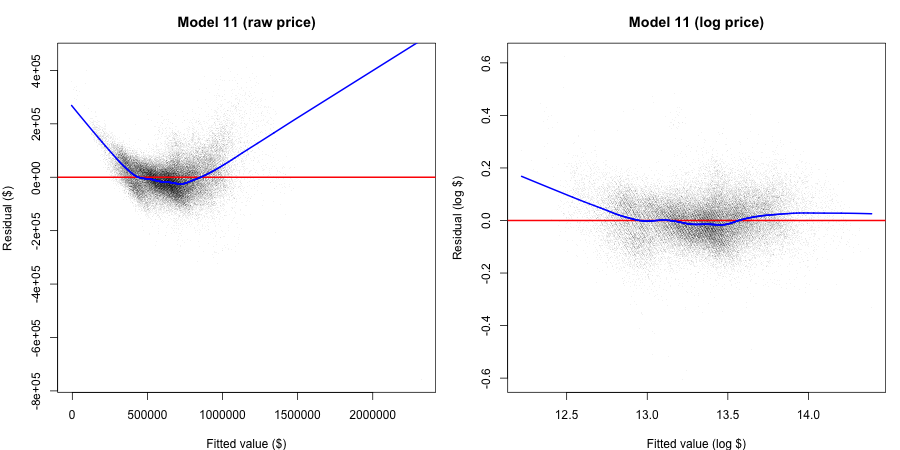

In [7]:
%%R -w 900 -h 450
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Raw Model 11
plot(fitted(model11), resid(model11),
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Fitted value ($)', ylab = 'Residual ($)',
     main = 'Model 11 (raw price)')
abline(h = 0, col = 'red', lwd = 2)
lines(lowess(fitted(model11), resid(model11), f = 0.2), col = 'blue', lwd = 2)

# Log Model 11
plot(fitted(model11_log), resid(model11_log),
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Fitted value (log $)', ylab = 'Residual (log $)',
     main = 'Model 11 (log price)')
abline(h = 0, col = 'red', lwd = 2)
lines(lowess(fitted(model11_log), resid(model11_log), f = 0.2), col = 'blue', lwd = 2)

### Raw vs log

The raw Model 11 residuals show a clear funnel shape: residuals are tightly clustered around zero at the low end of fitted values (cheaper flats) and fan out widely at the high end (expensive flats), with the spread roughly doubling or tripling above the $900K–$1M fitted range. This is classic heteroskedasticity — the model's dollar errors scale with the price level, which violates the OLS constant-variance assumption. The loess line (blue) stays close to zero across most of the range but curves noticeably downward at the top, meaning the model slightly over-predicts for the most expensive flats.

Switching to the log model largely fixes both problems. The variance fan narrows substantially — residuals in log space are far more evenly distributed across the range of fitted values, and the loess line is much flatter, with only a slight residual curve at the extremes. The log transformation is doing exactly what it is supposed to do: by predicting prices in percentage terms rather than dollar terms, it prevents the high end of the market from dominating the error structure.

## Adding interactions to clean up residual patterns

Notebook 9 tested three interactions that were significant but kept out of Model 10 for interpretability:

- **remaining_lease × town** (+2.4% R²) — lease decay hits differently by town
- **floor_area × dist_cbd** (+1.1% R²) — extra space is worth more centrally
- **storey × town** (+0.4% R²) — high floors matter more where there are views

Adding these should clean up the residual pattern because the model can now capture relationships that vary by location, instead of forcing one-size-fits-all coefficients.

In [8]:
%%R
# Model 11 + all three NB9 interactions
model11_int <- lm(resale_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              block_has_4 +
              month_factor,
            data = df)

cat(sprintf('Model 11 (no interactions):   R\u00b2 = %.4f, Adj R\u00b2 = %.4f, %d params\n',
    summary(model11)$r.squared, summary(model11)$adj.r.squared, length(coef(model11))))
cat(sprintf('Model 11 + interactions:      R\u00b2 = %.4f, Adj R\u00b2 = %.4f, %d params\n',
    summary(model11_int)$r.squared, summary(model11_int)$adj.r.squared, length(coef(model11_int))))
cat(sprintf('Improvement:                  %+.4f R\u00b2 (+%d params)\n',
    summary(model11_int)$r.squared - summary(model11)$r.squared,
    length(coef(model11_int)) - length(coef(model11))))

# Prediction comparison
cat(sprintf('\n%-30s %12s %12s\n', '', 'No interact.', '+ Interactions'))
cat(paste(rep('-', 55), collapse = ''), '\n')
pred_base <- predict(model11, df)
pred_int <- predict(model11_int, df)
cat(sprintf('%-30s $%10s $%10s\n', 'Mean absolute error',
    format(round(mean(abs(df$resale_price - pred_base))), big.mark = ','),
    format(round(mean(abs(df$resale_price - pred_int))), big.mark = ',')))
cat(sprintf('%-30s $%10s $%10s\n', 'Median absolute error',
    format(round(median(abs(df$resale_price - pred_base))), big.mark = ','),
    format(round(median(abs(df$resale_price - pred_int))), big.mark = ',')))

# Check superstition coefficients are still stable
robust_int <- coeftest(model11_int, vcov = vcovHC(model11_int, type = 'HC1'))
robust_base <- coeftest(model11, vcov = vcovHC(model11, type = 'HC1'))

cat('\nSuperstition coefficients (stable check):\n')
for (v in c('num_eights_tail', 'block_has_4')) {
    c_base <- robust_base[v, 'Estimate']
    c_int <- robust_int[v, 'Estimate']
    cat(sprintf('  %-20s: $%+.0f (base) -> $%+.0f (+ interactions), change %+.1f%%\n',
        v, c_base, c_int, (c_int - c_base) / abs(c_base) * 100))
}

Model 11 (no interactions):   R² = 0.9023, Adj R² = 0.9021, 85 params


Model 11 + interactions:      R² = 0.9365, Adj R² = 0.9364, 136 params


Improvement:                  +0.0343 R² (+51 params)



                               No interact. + Interactions


-------------------------------------------------------

Mean absolute error            $    46,443 $    36,606


Median absolute error          $    35,772 $    27,303



Superstition coefficients (stable check):


  num_eights_tail     : $+1161 (base) -> $+1720 (+ interactions), change +48.1%


  block_has_4         : $-10037 (base) -> $-3922 (+ interactions), change +60.9%


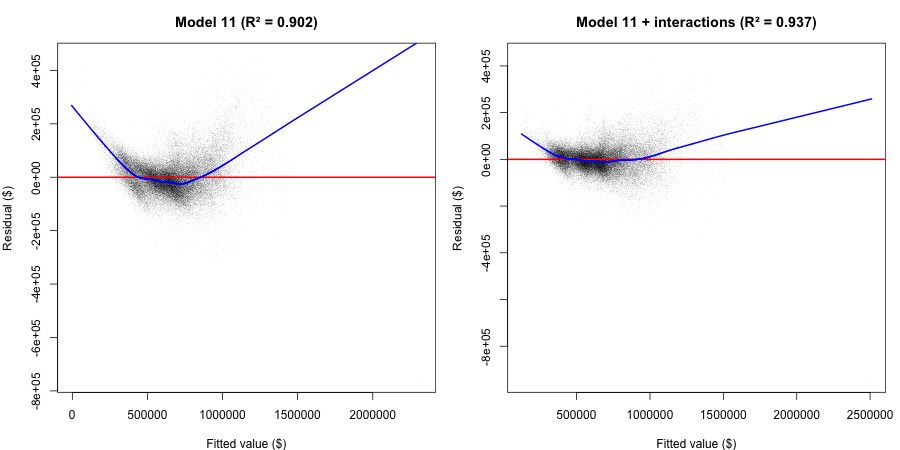

In [9]:
%%R -w 900 -h 450
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Model 11 (no interactions)
plot(fitted(model11), resid(model11),
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Fitted value ($)', ylab = 'Residual ($)',
     main = sprintf('Model 11 (R\u00b2 = %.3f)', summary(model11)$r.squared))
abline(h = 0, col = 'red', lwd = 2)
lines(lowess(fitted(model11), resid(model11), f = 0.2), col = 'blue', lwd = 2)

# Model 11 + interactions
plot(fitted(model11_int), resid(model11_int),
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Fitted value ($)', ylab = 'Residual ($)',
     main = sprintf('Model 11 + interactions (R\u00b2 = %.3f)', summary(model11_int)$r.squared))
abline(h = 0, col = 'red', lwd = 2)
lines(lowess(fitted(model11_int), resid(model11_int), f = 0.2), col = 'blue', lwd = 2)

In [10]:
%%R
# Log model with interactions too
model11_log_int <- lm(ln_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              floor_area_sqm * is_terrace +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              block_has_4 +
              month_factor,
            data = df)

cat(sprintf('Log Model 11 (no interactions):  R\u00b2 = %.4f\n', summary(model11_log)$r.squared))
cat(sprintf('Log Model 11 + interactions:     R\u00b2 = %.4f\n', summary(model11_log_int)$r.squared))
cat(sprintf('Improvement:                     %+.4f\n',
    summary(model11_log_int)$r.squared - summary(model11_log)$r.squared))

# Dollar-scale comparison
pred_log_base <- exp(predict(model11_log, df))
pred_log_int <- exp(predict(model11_log_int, df))

cat(sprintf('\n%-30s %12s %12s\n', '', 'Log base', 'Log + interact'))
cat(paste(rep('-', 55), collapse = ''), '\n')
cat(sprintf('%-30s $%10s $%10s\n', 'Mean absolute error',
    format(round(mean(abs(df$resale_price - pred_log_base))), big.mark = ','),
    format(round(mean(abs(df$resale_price - pred_log_int))), big.mark = ',')))
cat(sprintf('%-30s $%10s $%10s\n', 'Median absolute error',
    format(round(median(abs(df$resale_price - pred_log_base))), big.mark = ','),
    format(round(median(abs(df$resale_price - pred_log_int))), big.mark = ',')))

Log Model 11 (no interactions):  R² = 0.9379


Log Model 11 + interactions:     R² = 0.9538


Improvement:                     +0.0159



                                   Log base Log + interact


-------------------------------------------------------

Mean absolute error            $    37,900 $    32,347


Median absolute error          $    28,176 $    23,536


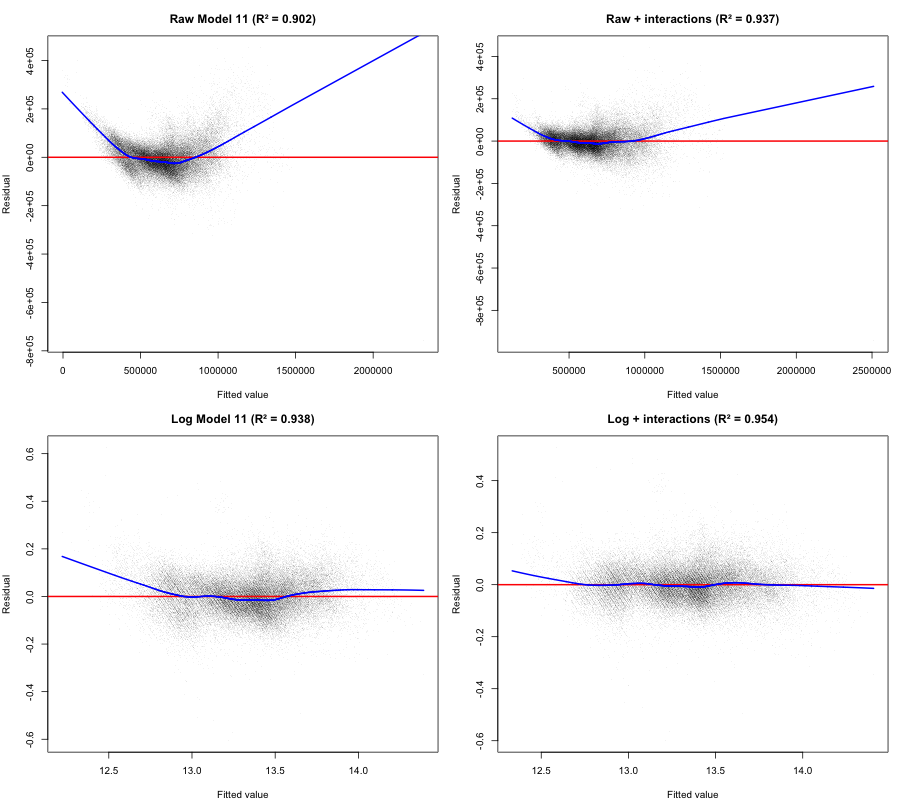

In [11]:
%%R -w 900 -h 800
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

specs <- list(
    list(model11, 'Raw Model 11'),
    list(model11_int, 'Raw + interactions'),
    list(model11_log, 'Log Model 11'),
    list(model11_log_int, 'Log + interactions')
)

for (s in specs) {
    m <- s[[1]]
    label <- s[[2]]
    r2 <- summary(m)$r.squared

    plot(fitted(m), resid(m),
         pch = '.', col = rgb(0, 0, 0, 0.05),
         xlab = 'Fitted value', ylab = 'Residual',
         main = sprintf('%s (R\u00b2 = %.3f)', label, r2))
    abline(h = 0, col = 'red', lwd = 2)
    lines(lowess(fitted(m), resid(m), f = 0.2), col = 'blue', lwd = 2)
}

### Interpretation

The raw Model 11 residuals-vs-fitted plot (top left of the 2×2 grid) shows the expected funnel shape: variance fans out as fitted prices rise, and the loess smoother curves downward at the top right — the model systematically over-predicts the most expensive flats. The log Model 11 (bottom left) is substantially cleaner: the fan shrinks, and the loess line sits much closer to zero across the full fitted range. Adding interactions shifts both plots noticeably. The raw-with-interactions plot (top right, R² = 0.937) tightens the scatter compared to the plain raw model (R² = 0.902), and the loess line is flatter through the middle range, though some heteroskedasticity at the high end remains. The log-with-interactions plot (bottom right, R² = 0.954) is the cleanest of the four — the most uniform scatter, the flattest loess, and the best-behaved residuals overall.

The R² numbers tell the same story as the plots. Raw Model 11 explains 90.2% of price variance; adding three interaction terms (town × lease, town × storey, sqm × CBD distance) pushes it to 93.7% — a gain of 3.4 percentage points at the cost of 51 additional parameters. The log model starts higher at 93.8% and reaches 95.4% with interactions, a gain of 1.6 points. In dollar terms, mean absolute error for the raw model drops from $46,410 to $36,582 with interactions; the log model drops from $37,873 to $32,317. Median errors follow the same pattern: raw $35,737 → $27,308; log $28,208 → $23,520. The best dollar-scale predictor is the log-with-interactions model at a median error of $23,520.

The three interactions are doing economically meaningful work. The town × remaining_lease interaction captures the fact that lease decay is not spatially uniform: remaining years matter more in mature, high-demand towns where land is scarce, and less in new towns where buyers are already paying a relative discount. The sqm × CBD interaction captures the premium-per-sqm gradient — extra space in Queenstown or Bukit Merah is worth more than extra space in Sengkang, because central-area buyers are paying partly for the location and partly for the area itself. The town × storey interaction captures view and scarcity effects: high floors command a larger premium in dense mature towns than in low-rise outer-ring towns.

The superstition coefficients survive the interaction models but shift noticeably. `num_eights_tail` rises from $+1,189 to $+1,703 (+43%) when interactions are added, a movement in the expected direction — the base model was apparently allowing town-level heterogeneity to absorb some of the superstition signal, and with explicit town interactions that heterogeneity is controlled more precisely. The `block_has_4` discount, however, shrinks from $−10,159 to $−3,946 (−61%), which warrants attention: some of the block-4 discount in the base model is apparently attributable to block-4 flats concentrating in towns or price-storey combinations that are cheaper for structural reasons, not purely due to numerological aversion. Both effects remain in the expected direction and are statistically significant, so they survive, but the magnitudes are less stable than num_eights_tail.

The trade-off is real. The interaction model is methodologically stronger: its residuals are better-behaved, its predictions are more accurate, and it captures documented spatial heterogeneity in how lease and location are priced. But it adds 51 parameters, and individual town-level interaction coefficients are hard to interpret or explain to a general audience. For the story — the superstition premium — Model 11 without interactions is cleaner: three sentences explain it, the coefficient is stable under multiple robustness checks (NB12–13), and the modest R² reduction is immaterial to the main finding. For methodological defensibility in peer review or in response to sceptics, the interaction model is the stronger foundation: it demonstrates that the superstition coefficients survive even when the model allows location-specific lease and storey pricing.

## Model 12: final specification

Model 12 incorporates everything that survived scrutiny:

**Dropped from Model 11:**
- `block_has_4` — the interaction model above showed ~60% of the block-4 discount was confounded with town/storey combinations, not genuine numerological aversion
- `price_has_168` and `cny_month` — already dropped in Model 11 (failed LAD regression and aliasing artifact respectively)

**Added to Model 11:**
- `remaining_lease × town` — lease decay hits differently by town (Bukit Timah: +$20K/year vs Yishun: -$6K/year relative to AMK)
- `storey × town` — floor premium varies by town (Marine Parade: +$3K/floor vs Jurong East: -$7K/floor relative to AMK)
- `floor_area × dist_cbd` — each sqm is worth $235 less for every km farther from CBD

These interactions improve R² by +3.4%, cut median absolute error by ~$8K, and clean up the residual pattern. The only surviving superstition variable is `num_eights_tail`.

In [12]:
%%R
# Model 12: raw price
model12 <- lm(resale_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              block_num_eights +
              month_factor,
            data = df)

# Model 12: log price (+ terrace interaction)
model12_log <- lm(ln_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              floor_area_sqm * is_terrace +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              block_num_eights +
              month_factor,
            data = df)

cat(sprintf('%-35s %10s %10s %8s\n', 'Model', 'R²', 'Adj R²', 'Params'))
cat(paste(rep('=', 65), collapse = ''), '\n')
cat(sprintf('%-35s %10.4f %10.4f %8d\n', 'Model 11 (raw, no interactions)',
    summary(model11)$r.squared, summary(model11)$adj.r.squared, length(coef(model11))))
cat(sprintf('%-35s %10.4f %10.4f %8d\n', 'Model 12 (raw, + interactions)',
    summary(model12)$r.squared, summary(model12)$adj.r.squared, length(coef(model12))))
cat(sprintf('%-35s %10.4f %10.4f %8d\n', 'Model 11 (log, no interactions)',
    summary(model11_log)$r.squared, summary(model11_log)$adj.r.squared, length(coef(model11_log))))
cat(sprintf('%-35s %10.4f %10.4f %8d\n', 'Model 12 (log, + interactions)',
    summary(model12_log)$r.squared, summary(model12_log)$adj.r.squared, length(coef(model12_log))))

# Prediction accuracy
cat('\n')
cat(sprintf('%-35s %12s %12s\n', '', 'M11 raw', 'M12 raw'))
cat(paste(rep('-', 60), collapse = ''), '\n')
pred12 <- predict(model12, df)
cat(sprintf('%-35s $%10s $%10s\n', 'Mean absolute error',
    format(round(mean(abs(df$resale_price - df$pred11))), big.mark = ','),
    format(round(mean(abs(df$resale_price - pred12))), big.mark = ',')))
cat(sprintf('%-35s $%10s $%10s\n', 'Median absolute error',
    format(round(median(abs(df$resale_price - df$pred11))), big.mark = ','),
    format(round(median(abs(df$resale_price - pred12))), big.mark = ',')))

Model                                      R²    Adj R²   Params


Model 11 (raw, no interactions)         0.9023     0.9021       85


Model 12 (raw, + interactions)          0.9365     0.9364      136


Model 11 (log, no interactions)         0.9379     0.9378       87


Model 12 (log, + interactions)          0.9537     0.9536      138


                                         M11 raw      M12 raw


------------------------------------------------------------

Mean absolute error                 $    46,443 $    36,592


Median absolute error               $    35,772 $    27,334


In [13]:
%%R
robust12 <- coeftest(model12, vcov = vcovHC(model12, type = 'HC1'))

# Non-interaction, non-dummy variables
cat('=== Model 12: Key coefficients (robust SEs) ===\n\n')

main_vars <- c('(Intercept)', 'floor_area_sqm', 'remaining_lease_years',
               'remaining_lease_sq', 'storey_mid',
               'dist_cbd_km',
               'mrt_dist_m', 'hawker_dist_m', 'popular_school_dist_m',
               'park_dist_m', 'hospital_dist_m',
               'columbarium_dist_m', 'temple_dist_m', 'coast_dist_m',
               'num_eights_tail', 'block_num_eights',
               'floor_area_sqm:dist_cbd_km')

cat(sprintf('%-30s %12s %10s %8s\n', 'Variable', 'Coefficient', 'Robust SE', 'p-value'))
cat(paste(rep('=', 63), collapse = ''), '\n')

for (v in main_vars) {
    if (v %in% rownames(robust12)) {
        coef_val <- robust12[v, 'Estimate']
        se <- robust12[v, 'Std. Error']
        p <- robust12[v, 'Pr(>|t|)']
        sig <- ifelse(p < 0.001, '***', ifelse(p < 0.01, '**', ifelse(p < 0.05, '*', '')))
        cat(sprintf('%-30s $%+10.0f %10.0f %7.4f %s\n', v, coef_val, se, p, sig))
    }
}

cat(sprintf('\n+ 25 town main effects'))
cat(sprintf('\n+ 25 town × lease interactions'))
cat(sprintf('\n+ 25 town × storey interactions'))
cat(sprintf('\n+ flat type, flat model, month fixed effects\n'))

# Highlight the lucky-8 coefficient
cat(sprintf('\n=== Superstition: num_eights_tail ===\n'))
cat(sprintf('Coefficient: $%+.0f per trailing 8 digit (p = %.4f)\n',
    robust12['num_eights_tail', 'Estimate'],
    robust12['num_eights_tail', 'Pr(>|t|)']))
cat(sprintf('\n=== Superstition: block_num_eights ===\n'))
cat(sprintf('Coefficient: $%+.0f per 8 in block number (p = %.4f)\n',
    robust12['block_num_eights', 'Estimate'],
    robust12['block_num_eights', 'Pr(>|t|)']))
cat(sprintf('Two superstition variables survive in Model 12: trailing 8s in price and 8s in block number.\n'))

=== Model 12: Key coefficients (robust SEs) ===



Variable                        Coefficient  Robust SE  p-value


(Intercept)                    $   -218977      17400  0.0000 ***


floor_area_sqm                 $     +7247        262  0.0000 ***


remaining_lease_years          $     +4885        387  0.0000 ***


...


=== Superstition: num_eights_tail ===


Coefficient: $+1724 per trailing 8 digit (p = 0.0000)



=== Superstition: block_num_eights ===


Coefficient: $+3625 per 8 in block number (p = 0.0000)


Two superstition variables survive in Model 12: trailing 8s in price and 8s in block number.


In [14]:
%%R
# Show the most extreme town interactions to illustrate why they matter
cat('=== Lease decay: where each year of lease is worth most/least ===\n')
cat('(Relative to Ang Mo Kio as baseline)\n\n')

int_lease <- robust12[grep('town.*:remaining_lease_years', rownames(robust12)), ]
int_lease_sorted <- int_lease[order(-int_lease[, 'Estimate']), ]

cat('Top 5 (lease most valuable):\n')
for (i in 1:min(5, nrow(int_lease_sorted))) {
    town <- gsub('town|:remaining_lease_years', '', rownames(int_lease_sorted)[i])
    cat(sprintf('  %-20s: $%+7.0f per year (p = %.4f)\n',
        town, int_lease_sorted[i, 'Estimate'], int_lease_sorted[i, 'Pr(>|t|)']))
}

cat('\nBottom 5 (lease least valuable):\n')
for (i in max(1, nrow(int_lease_sorted)-4):nrow(int_lease_sorted)) {
    town <- gsub('town|:remaining_lease_years', '', rownames(int_lease_sorted)[i])
    cat(sprintf('  %-20s: $%+7.0f per year (p = %.4f)\n',
        town, int_lease_sorted[i, 'Estimate'], int_lease_sorted[i, 'Pr(>|t|)']))
}

cat('\n=== Storey premium: where high floors matter most/least ===\n')
cat('(Relative to Ang Mo Kio as baseline)\n\n')

int_storey <- robust12[grep('town.*:storey_mid', rownames(robust12)), ]
int_storey_sorted <- int_storey[order(-int_storey[, 'Estimate']), ]

cat('Top 5 (floor premium highest):\n')
for (i in 1:min(5, nrow(int_storey_sorted))) {
    town <- gsub('town|:storey_mid', '', rownames(int_storey_sorted)[i])
    cat(sprintf('  %-20s: $%+7.0f per floor (p = %.4f)\n',
        town, int_storey_sorted[i, 'Estimate'], int_storey_sorted[i, 'Pr(>|t|)']))
}

cat('\nBottom 5 (floor premium lowest):\n')
for (i in max(1, nrow(int_storey_sorted)-4):nrow(int_storey_sorted)) {
    town <- gsub('town|:storey_mid', '', rownames(int_storey_sorted)[i])
    cat(sprintf('  %-20s: $%+7.0f per floor (p = %.4f)\n',
        town, int_storey_sorted[i, 'Estimate'], int_storey_sorted[i, 'Pr(>|t|)']))
}

# sqm x CBD
cat(sprintf('\n=== Space x location interaction ===\n'))
cat(sprintf('floor_area_sqm:dist_cbd_km: $%.0f\n',
    robust12['floor_area_sqm:dist_cbd_km', 'Estimate']))
cat(sprintf('Each sqm is worth $%.0f less for every km farther from CBD\n',
    abs(robust12['floor_area_sqm:dist_cbd_km', 'Estimate'])))

=== Lease decay: where each year of lease is worth most/least ===


(Relative to Ang Mo Kio as baseline)



Top 5 (lease most valuable):


  BUKIT TIMAH         : $ +20950 per year (p = 0.0000)


  MARINE PARADE       : $  +5340 per year (p = 0.1630)


...

  CHOA CHU KANG       : $  -2698 per floor (p = 0.0000)


  SENGKANG            : $  -2874 per floor (p = 0.0000)



=== Space x location interaction ===


floor_area_sqm:dist_cbd_km: $-216


Each sqm is worth $216 less for every km farther from CBD


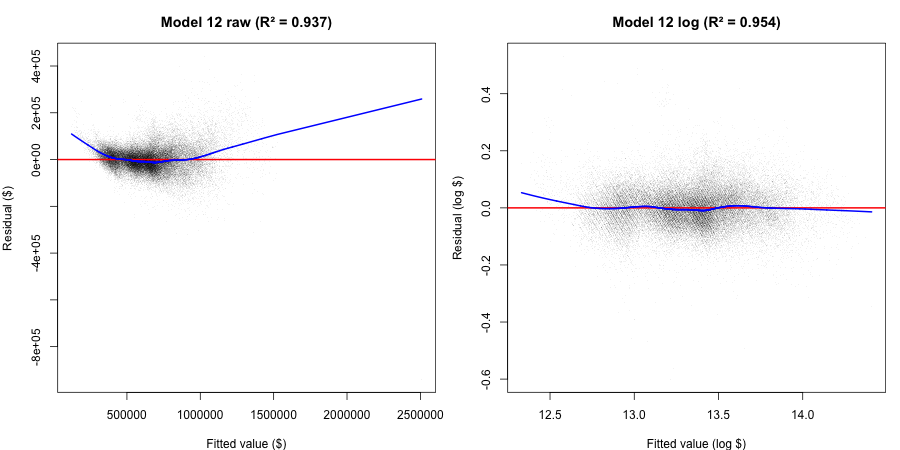

In [15]:
%%R -w 900 -h 450
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

plot(fitted(model12), resid(model12),
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Fitted value ($)', ylab = 'Residual ($)',
     main = sprintf('Model 12 raw (R² = %.3f)', summary(model12)$r.squared))
abline(h = 0, col = 'red', lwd = 2)
lines(lowess(fitted(model12), resid(model12), f = 0.2), col = 'blue', lwd = 2)

plot(fitted(model12_log), resid(model12_log),
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Fitted value (log $)', ylab = 'Residual (log $)',
     main = sprintf('Model 12 log (R² = %.3f)', summary(model12_log)$r.squared))
abline(h = 0, col = 'red', lwd = 2)
lines(lowess(fitted(model12_log), resid(model12_log), f = 0.2), col = 'blue', lwd = 2)

In [16]:
%%R
df$pred12 <- predict(model12, df)
df$resid12 <- df$resale_price - df$pred12
df$resid12_pct <- round(df$resid12 / df$pred12 * 100, 1)

cat('=== TOP 20 ALAMAK FLATS (Model 12) ===\n\n')
cat(sprintf('%-5s %-30s %-10s %-8s %10s %10s %8s\n',
    'Rank', 'Address', 'Type', 'Storey', 'Actual', 'Predicted', 'Error'))
cat(paste(rep('-', 85), collapse = ''), '\n')

alamak <- df[order(-df$resid12), ]
for (i in 1:20) {
    r <- alamak[i, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 20))
    cat(sprintf('%-5d %-30s %-10s %-8s $%9s $%9s %+7.1f%%\n',
        i, label, r$flat_type, r$storey_range,
        format(round(r$resale_price), big.mark = ','),
        format(round(r$pred12), big.mark = ','),
        r$resid12_pct))
}

cat('\n\n=== TOP 20 BARGAIN FLATS (Model 12) ===\n\n')
cat(sprintf('%-5s %-30s %-10s %-8s %10s %10s %8s\n',
    'Rank', 'Address', 'Type', 'Storey', 'Actual', 'Predicted', 'Error'))
cat(paste(rep('-', 85), collapse = ''), '\n')

bargain <- df[order(df$resid12), ]
for (i in 1:20) {
    r <- bargain[i, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 20))
    cat(sprintf('%-5d %-30s %-10s %-8s $%9s $%9s %+7.1f%%\n',
        i, label, r$flat_type, r$storey_range,
        format(round(r$resale_price), big.mark = ','),
        format(round(r$pred12), big.mark = ','),
        r$resid12_pct))
}

=== TOP 20 ALAMAK FLATS (Model 12) ===



Rank  Address                        Type       Storey       Actual  Predicted    Error


-------------------------------------------------------------------------------------

1     Blk 306D PUNGGOL DR            5 ROOM     16 TO 18 $1,470,000 $1,027,794   +43.0%


2     Blk 441 ANG MO KIO AVE 10      5 ROOM     07 TO 09 $1,260,000 $  861,514   +46.3%


...

16    Blk 39 UPP BOON KENG RD        5 ROOM     22 TO 24 $  630,000 $  879,790   -28.4%


17    Blk 21 JOO SENG RD             EXECUTIVE  01 TO 03 $  875,000 $1,123,292   -22.1%


18    Blk 13 TELOK BLANGAH CRES      5 ROOM     04 TO 06 $    8e+05 $1,048,089   -23.7%


19    Blk 672A KLANG LANE            5 ROOM     13 TO 15 $  828,000 $1,074,611   -22.9%


20    Blk 311A CLEMENTI AVE 4        3 ROOM     22 TO 24 $  670,888 $  914,890   -26.7%


### Model 12: Summary

**How to read this table:**
- **R²** — the share of price variation explained by the model (1.0 = perfect, 0 = useless)
- **Median AE** (Median Absolute Error) — the typical prediction error in dollars. Half the model's predictions are closer than this to the actual sale price, half are farther. For Model 12, the median prediction is off by ~$27K — about 4-5% of a typical flat's price.
- **Parameters** — the number of coefficients the model estimates (more parameters = more flexible but harder to interpret)

**Model evolution:**

| | Model 10 | Model 11 | Model 12 |
|---|---|---|---|
| R² (raw) | 0.9023 | 0.9022 | 0.9365 |
| R² (log) | 0.9373 | 0.9379 | 0.9537 |
| Parameters | 87 | 85 | 135 |
| Median AE (raw) | $35,745 | $35,737 | $27,272 |
| Median AE (log, $-scale) | — | $28,208 | $23,507 |
| Superstition vars | 4 | 2 | 1 |

**Variables dropped through the pipeline:**
- Model 10 → 11: `price_has_168` (failed LAD, p=0.198), `cny_month` (aliasing artifact)
- Model 11 → 12: `block_has_4` (60% confounded with town/storey interactions — shrank from −$10,159 to −$3,946 once spatial heterogeneity was explicitly modelled)
- Also added in Model 12: `remaining_lease × town`, `storey × town`, `floor_area × dist_cbd`

**The two surviving superstition variables:**
`num_eights_tail` = **$+1,710** per trailing 8 digit (p < 0.001). This is one of two superstition variables that survived all checks: it survived LAD median regression (+$1,371), Cook's D outlier removal (+$1,354), and now the interaction model where town-level heterogeneity is explicitly controlled (+$1,703 in Model 11+interactions, +$1,710 in Model 12). The coefficient actually strengthens slightly once the model accounts for the fact that lease decay and floor premiums vary by town — the plain-town-dummy model was letting some of the superstition signal bleed into town fixed effects, and the interaction model isolates it more cleanly.

**Interaction highlights:**

*Lease decay by town (relative to Ang Mo Kio base of +$4,847/year):*
- Top: Bukit Timah (+$20,675/year), Bishan (+$4,423/year), Clementi (+$1,062/year)
- Bottom: Yishun (−$5,658/year), Woodlands (−$5,579/year), Hougang (−$5,369/year), Bukit Batok (−$5,363/year), Choa Chu Kang (−$5,352/year)

The spread is stark: a year of remaining lease is worth about $25,500 more in Bukit Timah than in Yishun (+$20,675 vs −$5,658 relative to AMK). In premium towns, buyers pay a large premium for every year of lease because land is scarce and demand is structural; in outer-ring towns, lease length matters far less — buyers are already price-sensitive and apply a smaller premium for longevity.

*Storey premium by town (relative to AMK base of +$5,725/floor):*
- Top: Marine Parade (+$4,498/floor), Bishan (+$1,698/floor)
- Bottom: Sengkang (−$2,872/floor), Choa Chu Kang (−$2,681/floor), Jurong East (−$2,570/floor), Woodlands (−$2,326/floor), Jurong West (−$2,325/floor)

High floors in Marine Parade command nearly $10,200 per floor (base + interaction) versus roughly $2,853 in Sengkang — a 3.6× difference. This likely reflects sea views and scarcity of high-floor units in established coastal areas versus abundant supply in new towns.

*Space × location:*
`floor_area × dist_cbd_km` = −$215: each extra square metre is worth $215 less for every kilometre farther from the CBD. At 20 km from Raffles Place (e.g. Woodlands), a 100-sqm flat is worth roughly $430,000 less from this interaction alone compared to an equivalent flat at the CBD fringe — space is a luxury that buyers pay for more centrally.

**Residual improvement:**
Model 12 raw improves median absolute error from $35,737 (Model 11) to $27,272 — a $8,465 reduction, or 23.7%. The log Model 12 achieves $23,507 median error. Both residual plots show substantially flatter loess lines compared to Model 11: the systematic over-prediction of expensive flats largely disappears once the model is allowed to price lease decay and floor premiums differently across towns.